# 07 — Country Intelligence Report Notebook

This notebook mirrors the Country Report page. It combines similarity, clustering, PCA position, anomaly detection, and time-series trend into one academic report for a selected country.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook paths: this assumes the notebooks folder is copied into your project root.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATHS = [
    PROJECT_ROOT / "sample_datasets" / "world_panel_2010_2023.csv",
    PROJECT_ROOT / "data" / "raw" / "world_panel_2010_2023.csv",
    Path("/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/sample_datasets/world_panel_2010_2023.csv"),
]
DATA_PATH = next((p for p in DATA_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find world_panel_2010_2023.csv. Put this notebook folder in the project root.")

CHARTS_DIR = PROJECT_ROOT / "charts" / Path.cwd().name.replace(" ", "_")
if Path.cwd().name != "notebooks":
    # when executed from project root, use the notebook-specific folder manually below
    CHARTS_DIR = PROJECT_ROOT / "charts" / "07_country_report"
PROCESSED_DIR = PROJECT_ROOT / "after_processing_dataset"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def save_mpl(name, dpi=160):
    path = CHARTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved chart: {path}")
    plt.show()

def save_df(df, name):
    path = PROCESSED_DIR / name
    df.to_csv(path, index=False)
    print(f"Saved dataset: {path}")
    return path

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head()

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans

numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_cols = [c for c in numeric_cols if c != "year"]
country_profile = df.groupby(["country", "code", "region"], as_index=False)[feature_cols].mean()
X_imp = SimpleImputer(strategy="median").fit_transform(country_profile[feature_cols])
X = StandardScaler().fit_transform(X_imp)

Loaded: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/sample_datasets/world_panel_2010_2023.csv
Shape: (336, 22)


## 1. Select country

In [2]:
selected_country = "United States" if "United States" in country_profile["country"].values else country_profile["country"].iloc[0]
idx = country_profile.index[country_profile["country"] == selected_country][0]
print("Selected country:", selected_country)
display(country_profile.loc[[idx]])

Selected country: Algeria


,country,code,region,gdp_per_capita,hdi,life_expectancy,literacy_rate,internet_usage_pct,co2_per_capita,fertility_rate,...,education_spending_pct,health_spending_pct,gini_index,political_stability,urbanization_rate,unemployment_rate,renewable_energy_pct,access_to_water_pct,maternal_mortality,population
0,Algeria,DZA,Africa,5143.785714,0.5038,72.781429,89.336429,45.450714,1.327429,4.192143,...,5.555786,7.769714,48.761429,0.157707,55.727857,12.152857,44.98,70.582143,503.871429,315575777.5


## 2. Similar countries using cosine similarity

In [3]:
sim = cosine_similarity(X)
sim_scores = pd.Series(sim[idx], index=country_profile["country"])
similar = sim_scores.drop(selected_country).sort_values(ascending=False).head(8).reset_index()
similar.columns = ["similar_country", "cosine_similarity"]
display(similar.round(4))
save_df(similar, f"{selected_country}_similar_countries.csv".replace(" ", "_"))

,similar_country,cosine_similarity
0,Nigeria,0.9925
1,Jordan,0.9888
2,Palestine,0.9883
3,Brazil,0.9787
4,Yemen,0.9681
5,Morocco,0.9313
6,Egypt,0.8974
7,Somalia,0.8642


Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/Algeria_similar_countries.csv


PosixPath('/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/Algeria_similar_countries.csv')

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/country_report_similar_countries.png


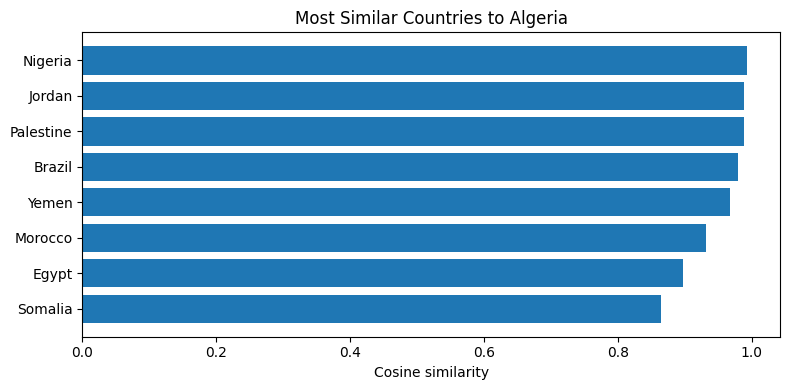

In [4]:
plt.figure(figsize=(8,4))
plt.barh(similar["similar_country"].iloc[::-1], similar["cosine_similarity"].iloc[::-1])
plt.title(f"Most Similar Countries to {selected_country}")
plt.xlabel("Cosine similarity")
save_mpl("country_report_similar_countries.png")

## 3. Cluster assignment

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X)
country_profile["cluster"] = clusters
selected_cluster = int(country_profile.loc[idx, "cluster"])
cluster_members = country_profile[country_profile["cluster"] == selected_cluster][["country","code","region","cluster"]]
print("Selected cluster:", selected_cluster)
display(cluster_members)
save_df(country_profile, "country_report_with_clusters.csv")

Selected cluster: 2


,country,code,region,cluster
0,Algeria,DZA,Africa,2
7,India,IND,Asia,2
11,Nigeria,NGA,Africa,2
13,Palestine,PSE,Asia,2
17,Somalia,SOM,Africa,2
23,Yemen,YEM,Asia,2


Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_report_with_clusters.csv


PosixPath('/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_report_with_clusters.csv')

## 4. PCA position

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/country_report_pca_position.png


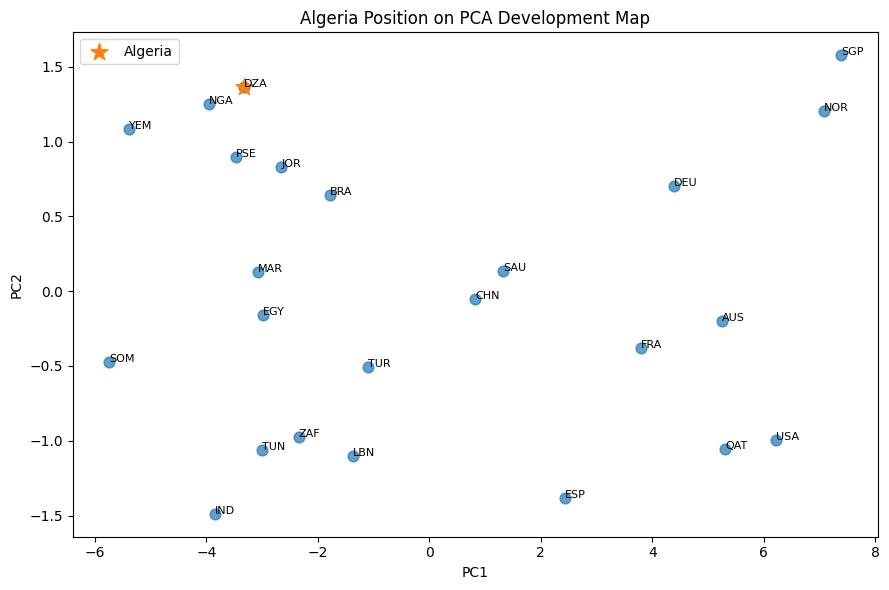

Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_report_pca_scores.csv


PosixPath('/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_report_pca_scores.csv')

In [6]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
pca_df = country_profile[["country","code","region","cluster"]].copy()
pca_df["PC1"] = coords[:,0]
pca_df["PC2"] = coords[:,1]

plt.figure(figsize=(9,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], s=60, alpha=0.7)
sel = pca_df[pca_df["country"] == selected_country].iloc[0]
plt.scatter([sel.PC1], [sel.PC2], s=160, marker="*", label=selected_country)
for _, r in pca_df.iterrows():
    plt.text(r["PC1"], r["PC2"], r["code"], fontsize=8)
plt.title(f"{selected_country} Position on PCA Development Map")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
save_mpl("country_report_pca_position.png")
save_df(pca_df, "country_report_pca_scores.csv")

## 5. Anomaly status

In [7]:
iso = IsolationForest(contamination=min(0.15, max(0.05, 3/len(country_profile))), random_state=42, n_estimators=200)
anom_pred = iso.fit_predict(X)
anom_score = iso.decision_function(X)
country_profile["anomaly"] = (anom_pred == -1).astype(int)
country_profile["anomaly_score"] = anom_score
selected_anomaly = country_profile.loc[idx, ["country","anomaly","anomaly_score"]]
display(selected_anomaly.to_frame().T)
save_df(country_profile[["country","code","region","anomaly","anomaly_score"]], "country_report_anomaly_scores.csv")

,country,anomaly,anomaly_score
0,Algeria,0,0.162433


Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_report_anomaly_scores.csv


PosixPath('/Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/country_report_anomaly_scores.csv')

## 6. Indicator radar-style comparison against global average

,indicator,Algeria,global_average
0,gdp_per_capita,5143.786,30617.678
1,hdi,0.504,0.649
2,life_expectancy,72.781,76.749
3,internet_usage_pct,45.451,52.477
4,infant_mortality,60.085,42.871
5,unemployment_rate,12.153,10.274


Saved dataset: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/after_processing_dataset/Algeria_indicator_vs_global_average.csv
Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/country_report_indicator_comparison.png


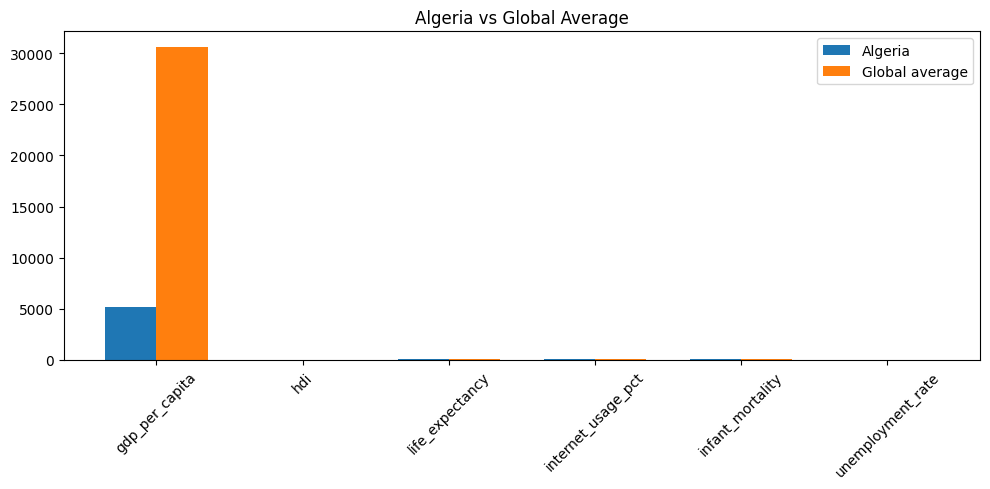

In [8]:
selected_features = ["gdp_per_capita","hdi","life_expectancy","internet_usage_pct","infant_mortality","unemployment_rate"]
comparison = pd.DataFrame({
    "indicator": selected_features,
    selected_country: country_profile.loc[idx, selected_features].values,
    "global_average": country_profile[selected_features].mean().values
})
display(comparison.round(3))
save_df(comparison, f"{selected_country}_indicator_vs_global_average.csv".replace(" ", "_"))

x = np.arange(len(selected_features))
width = 0.35
plt.figure(figsize=(10,5))
plt.bar(x-width/2, comparison[selected_country], width, label=selected_country)
plt.bar(x+width/2, comparison["global_average"], width, label="Global average")
plt.xticks(x, selected_features, rotation=45)
plt.title(f"{selected_country} vs Global Average")
plt.legend()
save_mpl("country_report_indicator_comparison.png")

## 7. Time-series note for selected country

Saved chart: /Users/bilal/Downloads/World_Development_FINAL_PAGED-2/charts/notebooks/country_report_time_trend.png


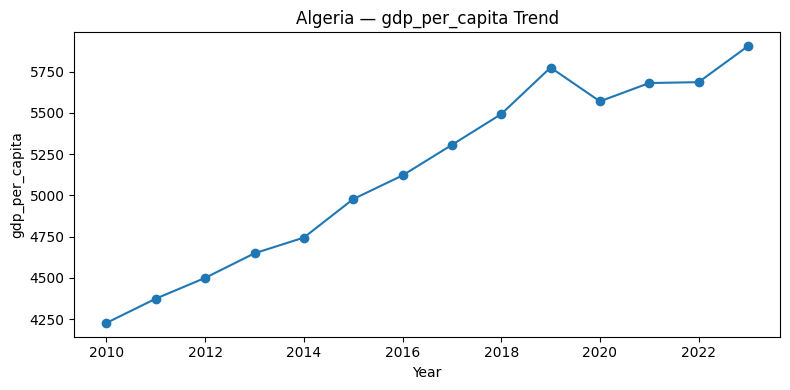

gdp_per_capita changed from 4228.10 to 5904.30, change = 1676.20.


In [9]:
indicator = "gdp_per_capita"
series = df[df["country"] == selected_country].sort_values("year")[["year", indicator]]
plt.figure(figsize=(8,4))
plt.plot(series["year"], series[indicator], marker="o")
plt.title(f"{selected_country} — {indicator} Trend")
plt.xlabel("Year")
plt.ylabel(indicator)
save_mpl("country_report_time_trend.png")
first, last = series[indicator].iloc[0], series[indicator].iloc[-1]
print(f"{indicator} changed from {first:.2f} to {last:.2f}, change = {last-first:.2f}.")

## 8. Auto-generated text report

In [10]:
report = f"""
Country Intelligence Report: {selected_country}

1. Similarity:
The most similar countries are: {', '.join(similar['similar_country'].head(5))}.

2. Cluster:
{selected_country} belongs to cluster {selected_cluster}, which contains {len(cluster_members)} countries.

3. PCA Position:
On the PCA map, {selected_country} is located at PC1={sel.PC1:.3f}, PC2={sel.PC2:.3f}.

4. Anomaly Status:
The country is classified as {'an anomaly' if int(selected_anomaly['anomaly']) == 1 else "normal"} by Isolation Forest.

5. Time Series:
For {indicator}, the value changed from {first:.2f} to {last:.2f} between {int(series.year.min())} and {int(series.year.max())}.
"""
print(report)
(PROCESSED_DIR / f"{selected_country}_country_intelligence_report.txt".replace(" ", "_")).write_text(report, encoding="utf-8")


Country Intelligence Report: Algeria

1. Similarity:
The most similar countries are: Nigeria, Jordan, Palestine, Brazil, Yemen.

2. Cluster:
Algeria belongs to cluster 2, which contains 6 countries.

3. PCA Position:
On the PCA map, Algeria is located at PC1=-3.320, PC2=1.368.

4. Anomaly Status:
The country is classified as normal by Isolation Forest.

5. Time Series:
For gdp_per_capita, the value changed from 4228.10 to 5904.30 between 2010 and 2023.



458